In [1]:
# ==========================================================
# SEMI-SUPERVISED DATASET DIRECTORY (BALANCED)
# ==========================================================
# FIX: this now points directly at the directory your preprocessing
# pipeline (P3_fixed_final_Pipeline_v11, cell 14) already builds for you --
# Semi_Supervised_Balanced/{labeled_train, unlabeled_train, val, test}.
#
# labeled_train / unlabeled_train / val come from the AUGMENTED pool
# (genuinely balanced, ~6500/class before splitting). test is the raw,
# untouched, held-out test set reused from Semi_Supervised_Split -- the
# SAME test set used by your other models, so results are comparable.
#
# IMPORTANT: rerun the preprocessing pipeline from a clean state first
# (delete stale classification_folders / Augmented_Pool / Balanced_dataset /
# Semi_Supervised_Balanced dirs) so Suspicious_Malignant is merged and this
# folder reflects the current 3-class pipeline.
print("start")

import os

semi_supervised_dir = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"

print("Paths defined and ready")
print("done1")

start
Paths defined and ready
done1


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)

Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import shutil
import random
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [4]:
# ==========================================================
# VERIFY THE PIPELINE-GENERATED SPLIT (no re-splitting needed)
# ==========================================================
# FIX: this cell previously re-split "Balanced_dataset" (raw, NOT
# augmented/balanced, and NOT your real test set) into its own ad-hoc
# train_labeled/train_unlabeled/val/test. That data was never balanced
# and its "test" was carved out of what should have been train-only data,
# making results incomparable to your other models.
#
# The pipeline already built the correct split -- just confirm it's there.
print("start")

target_base_dir = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"
splits = ['labeled_train', 'unlabeled_train', 'val', 'test']

for split in splits:
    split_dir = os.path.join(target_base_dir, split)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"'{split_dir}' not found. Run the preprocessing pipeline "
            "(P3_fixed_final_Pipeline_v11) through cell 14 first."
        )
    classes_found = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    counts = {
        cls: len(os.listdir(os.path.join(split_dir, cls)))
        for cls in classes_found
    }
    print(f"{split}: {counts}")

print("done1")

start
labeled_train: {'Benign': 1714, 'Malignant': 1714, 'Normal': 1715}
unlabeled_train: {'Benign': 4286, 'Malignant': 4286, 'Normal': 4285}
val: {'Benign': 931, 'Malignant': 1239, 'Normal': 795}
test: {'Benign': 888, 'Malignant': 1266, 'Normal': 789}
done1


In [5]:
# ==========================================================
# CONFIGURATION & PARAMETERS
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3  # FIX: was 4 -- Suspicious_Malignant is merged into Malignant in the pipeline
BATCH_SIZE = 32
EPOCHS = 150

print("done1")

start
done1


In [6]:
# ==========================================================
# DATA FLOW GENERATORS SETUP
# ==========================================================
print("start")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"  # FIX: use the pipeline-built dir

train_labeled_generator = train_datagen.flow_from_directory(
    os.path.join(base_path, 'labeled_train'),  # FIX: matches pipeline's folder name,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

train_unlabeled_generator = test_val_datagen.flow_from_directory(
    os.path.join(base_path, 'unlabeled_train'),  # FIX: matches pipeline's folder name,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

val_generator = test_val_datagen.flow_from_directory(
    os.path.join(base_path, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Sanity check: fail loudly instead of silently training on the wrong data
assert train_labeled_generator.num_classes == 3, (
    f"Expected 3 classes, found {train_labeled_generator.num_classes}. "
    "Rerun the preprocessing pipeline from a clean state."
)
assert set(val_generator.filenames) != set(test_generator.filenames), (
    "val_generator and test_generator appear to overlap."
)

print("done1")

start
Found 5143 images belonging to 3 classes.
Found 12857 images belonging to 3 classes.
Found 2965 images belonging to 3 classes.
Found 2943 images belonging to 3 classes.
done1


In [7]:
# ==========================================================
# MODEL INITIALIZATION (EfficientNetB3 Backbone)
# ==========================================================
print("start")

# Initialize all metrics
f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall') # <-- 1. Initialized Recall

def get_EfficientNetB3():
    # 1. Load the EfficientNetB3 Base Model with ImageNet weights
    base_model = EfficientNetB3(
        input_shape=MODEL_INPUT_SIZE,
        weights='imagenet',
        include_top=False
    )

    # Freeze the base model layers for Phase 1
    base_model.trainable = False

    # 2. Build the Custom Top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    # 3. Compile the model
    optimizer = Adam(learning_rate=0.0001)

    # 2. Added recall_metric to the compile step
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric], 
        optimizer=optimizer
    )

    return model

model = get_EfficientNetB3()

# Display the model architecture
model.summary()

print("done1")

start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 288, 288, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 288, 288, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 288, 288, 3)  0           ['normalization[0][0]']

In [8]:
# ==========================================================
# TRAINING MONITORING CALLBACKS
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=11,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint_initial = ModelCheckpoint(
    "EfficientNetB3_SemiSupervised_Initial.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,  # <--- FIX APPLIED HERE
    mode='max',
    verbose=1
)

print("done")

start
done


In [9]:
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")

start
done1


In [10]:
# ==========================================================
# PHASE 1: INITIAL MODEL TRAINING (15% Labeled Subset)
# ==========================================================
print("start")

history_initial = model.fit(
    train_labeled_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint_initial, lr_callback]
)

print("Initial baseline model training complete")

start
Epoch 1/150
161/161 [==============================] - ETA: 0s - loss: 1.1184 - accuracy: 0.3955 - f1_score: 0.3946 - precision: 0.4472 - recall: 0.1581
Epoch 1: val_f1_score improved from -inf to 0.48876, saving model to EfficientNetB3_SemiSupervised_Initial.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 185s 1s/step - loss: 1.1184 - accuracy: 0.3955 - f1_score: 0.3946 - precision: 0.4472 - recall: 0.1581 - val_loss: 1.0229 - val_accuracy: 0.4998 - val_f1_score: 0.4888 - val_precision: 0.6485 - val_recall: 0.2121 - lr: 1.0000e-04
Epoch 2/150
161/161 [==============================] - ETA: 0s - loss: 1.0097 - accuracy: 0.4982 - f1_score: 0.4954 - precision: 0.5805 - recall: 0.2712
Epoch 2: val_f1_score improved from 0.48876 to 0.55174, saving model to EfficientNetB3_SemiSupervised_Initial.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 68s 420ms/step - loss: 1.0097 - accuracy: 0.4982 - f1_s

In [11]:
# ==========================================================
# PHASE 2 & 3: ITERATIVE SEMI-SUPERVISED SELF-TRAINING LOOP
# ==========================================================
print("start")
base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"  # FIX: use the pipeline-built dir
train_dir = os.path.join(base_path, 'labeled_train')  # FIX: matches pipeline's folder name
unlabeled_dir = os.path.join(base_path, 'unlabeled_train')  # FIX: matches pipeline's folder name
train_combined_dir = os.path.join(base_path, 'train_combined')


NUM_ITERATIONS = 5
EPOCHS_PER_ITERATION = 7
CONFIDENCE_THRESHOLD = 0.90

class CombinedHistory:
    def __init__(self):
        self.history = {
            'loss': [], 'val_loss': [],
            'f1_score': [], 'val_f1_score': [],
            'precision': [], 'val_precision': [],
            'accuracy': [], 'val_accuracy': []
        }
history_final = CombinedHistory()

print("Initializing combined training directory with baseline labeled data...")
if os.path.exists(train_combined_dir):
    shutil.rmtree(train_combined_dir)
os.makedirs(train_combined_dir, exist_ok=True)

for class_name in os.listdir(train_dir):
    src_class_dir = os.path.join(train_dir, class_name)
    dst_class_dir = os.path.join(train_combined_dir, class_name)
    if os.path.isdir(src_class_dir):
        shutil.copytree(src_class_dir, dst_class_dir)

# --- START THE ITERATIVE LOOP ---
for iteration in range(NUM_ITERATIONS):
    print(f"\n==================================================")
    print(f" STARTING ITERATION {iteration + 1} / {NUM_ITERATIONS}")
    print(f"==================================================")

    predict_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    unlabeled_generator = predict_datagen.flow_from_directory(
        unlabeled_dir,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    if unlabeled_generator.samples == 0:
        print("No remaining images left in the unlabeled directory! Ending loop early.")
        break

    print(f"Predicting on {unlabeled_generator.samples} remaining unlabeled images...")
    predictions = model.predict(unlabeled_generator, verbose=1)

    # FIX: derive dynamically instead of hardcoding a leftover 4th class
    inv_class_indices = {v: k for k, v in train_labeled_generator.class_indices.items()}
    filenames = unlabeled_generator.filenames

    moved_count = 0
    for i, pred in enumerate(predictions):
        max_confidence = np.max(pred)

        if max_confidence >= CONFIDENCE_THRESHOLD:
            predicted_class_idx = np.argmax(pred)
            predicted_class_name = inv_class_indices[predicted_class_idx]

            src_file_path = os.path.join(unlabeled_dir, filenames[i])
            file_basename = os.path.basename(filenames[i])
            dst_file_path = os.path.join(train_combined_dir, predicted_class_name, file_basename)

            if os.path.exists(src_file_path):
                shutil.move(src_file_path, dst_file_path)
                moved_count += 1

    print(f"Iteration {iteration + 1}: Successfully incorporated {moved_count} new pseudo-labels.")

    train_combined_generator = train_datagen.flow_from_directory(
        train_combined_dir,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric],
        optimizer=Adam(learning_rate=1e-5)
    )

    checkpoint_final = ModelCheckpoint(
        "EfficientNetB3_SemiSupervised_Final.h5",
        monitor='val_f1_score',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )

    print(f"Training model for {EPOCHS_PER_ITERATION} epochs on updated dataset...")
    history = model.fit(
        train_combined_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PER_ITERATION,
        callbacks=[early_stop, reduce_lr, checkpoint_final, lr_callback]
    )

    for key in history_final.history.keys():
        if key in history.history:
            history_final.history[key].extend(history.history[key])

print("\nIterative Semi-Supervised training loop successfully completed!")
print("done1")

start
Initializing combined training directory with baseline labeled data...

 STARTING ITERATION 1 / 5
Found 12857 images belonging to 3 classes.
Predicting on 12857 remaining unlabeled images...
402/402 [==============================] - 191s 474ms/step
Iteration 1: Successfully incorporated 925 new pseudo-labels.
Found 6068 images belonging to 3 classes.
Training model for 7 epochs on updated dataset...
Epoch 1/7
190/190 [==============================] - ETA: 0s - loss: 0.5921 - accuracy: 0.7340 - f1_score: 0.6973 - precision: 0.7622
Epoch 1: val_f1_score improved from -inf to 0.65863, saving model to EfficientNetB3_SemiSupervised_Final.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
190/190 [==============================] - 80s 396ms/step - loss: 0.5921 - accuracy: 0.7340 - f1_score: 0.6973 - precision: 0.7622 - val_loss: 0.7038 - val_accuracy: 0.6583 - val_f1_score: 0.6586 - val_precision: 0.7077 - lr: 1.0000e-05
Epoch 2/7
190/190 [==============================] - ETA: 0s - l

In [12]:
# 1. Rebuild the model architecture blueprint first
# (This function now automatically compiles the model with Accuracy, F1, Precision, and Recall)
model = get_EfficientNetB3()

# 2. Load the weights directly into the blueprint
# Note: .load_weights() does not require a custom_objects dictionary!
model.load_weights("EfficientNetB3_SemiSupervised_Final.h5")

print("Model weights loaded successfully!")

Model weights loaded successfully!


In [13]:
# ==========================================================
# RELOAD COMBINED TRAINING SET AFTER THE SELF-TRAINING LOOP
# ==========================================================
# FIX: base_path and folder names now match the pipeline-built directory.
base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"
train_dir = os.path.join(base_path, 'labeled_train')
unlabeled_dir = os.path.join(base_path, 'unlabeled_train')
train_combined_dir = os.path.join(base_path, 'train_combined')
train_combined_generator = train_datagen.flow_from_directory(
    train_combined_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
    )


Found 16228 images belonging to 3 classes.


start


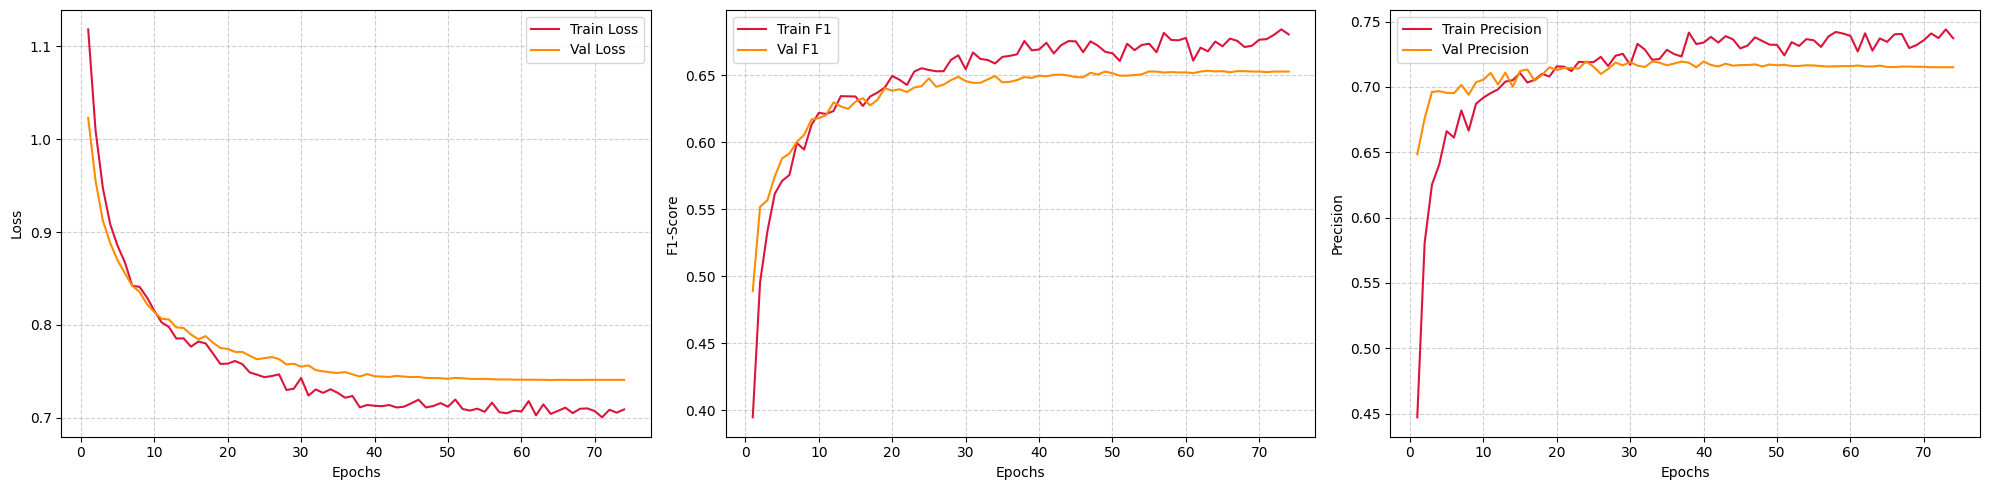

done


In [14]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 1 (INITIAL TRAINING)
# ==========================================================
print("start")

# Make sure history_initial is available from your Phase 1 model.fit run
if 'history_initial' in locals() or 'history_initial' in globals():
    epochs_range = range(1, len(history_initial.history['loss']) + 1)

    # 1x3 Grid for Loss, F1, and Precision
    plt.figure(figsize=(20, 5))

    # 1. Loss Curve
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history_initial.history['loss'], label='Train Loss', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_loss'], label='Val Loss', color='darkorange')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. F1-Score Curve
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history_initial.history['f1_score'], label='Train F1', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_f1_score'], label='Val F1', color='darkorange')

    plt.xlabel('Epochs')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. Precision Curve
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history_initial.history['precision'], label='Train Precision', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_precision'], label='Val Precision', color='darkorange')

    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("EfficientNetB3_SemiSupervised_Initial_Learning_Curves_Balanced.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_initial variable not found. Did Phase 1 execute properly?")

print("done")

start


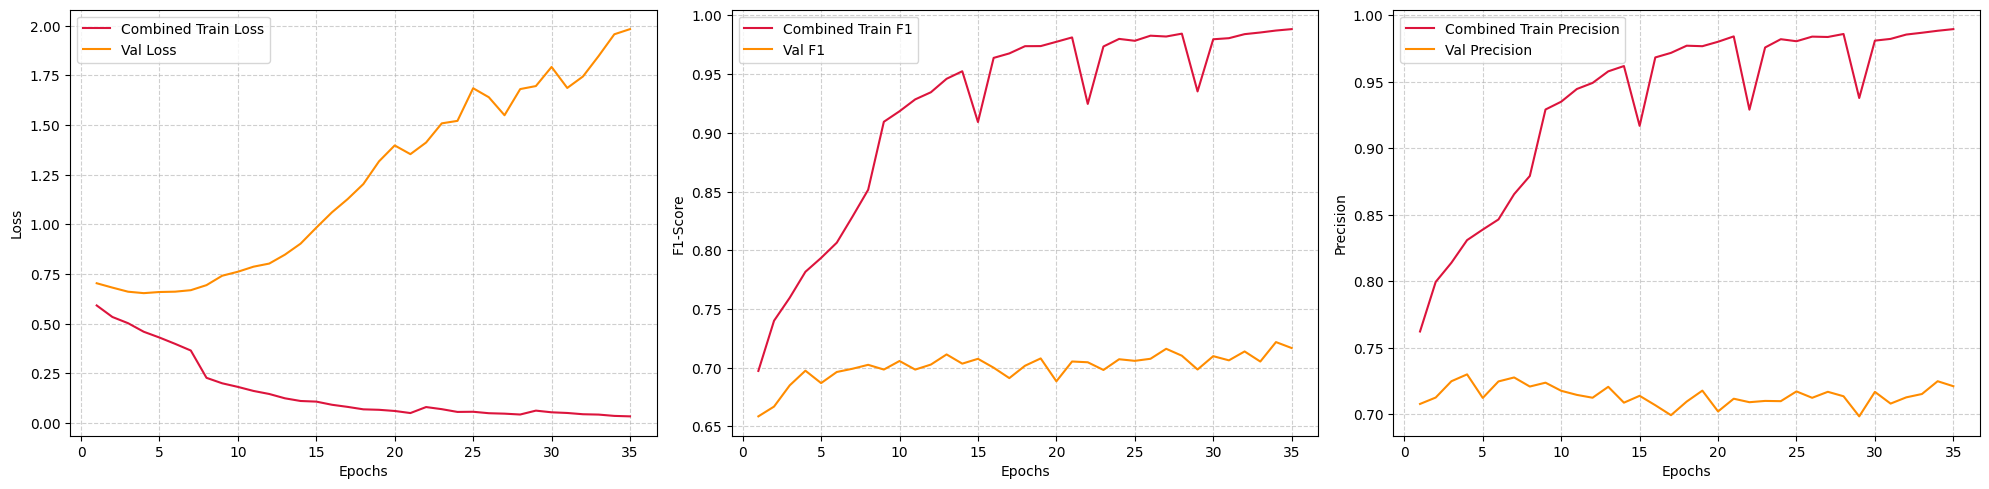

done1


In [15]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 3 (SEMI-SUPERVISED TRAINING)
# ==========================================================
print("start")

# Make sure history_final is available from your Phase 3 model.fit run
if 'history_final' in locals() or 'history_final' in globals():
    epochs_range = range(1, len(history_final.history['loss']) + 1)

    # 1x3 Grid for Loss, F1, and Precision
    plt.figure(figsize=(20, 5))

    # 1. Loss Curve
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history_final.history['loss'], label='Combined Train Loss', color='crimson')
    plt.plot(epochs_range, history_final.history['val_loss'], label='Val Loss', color='darkorange')
  
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. F1-Score Curve
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history_final.history['f1_score'], label='Combined Train F1', color='crimson')
    plt.plot(epochs_range, history_final.history['val_f1_score'], label='Val F1', color='darkorange')

    plt.xlabel('Epochs')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. Precision Curve
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history_final.history['precision'], label='Combined Train Precision', color='crimson')
    plt.plot(epochs_range, history_final.history['val_precision'], label='Val Precision', color='darkorange')
   
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("EfficientNetB3_SemiSupervised_Final_Learning_Curves_(Balanced Dataset).pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_final variable not found. Did Phase 3 execute properly?")

print("done1")

In [16]:
# ==========================================================
# FINAL EVALUATION: TRAINING, VALIDATION, AND TEST SETS
# ==========================================================
print("start")

# Load final semi-supervised optimal parameters
model.load_weights("EfficientNetB3_SemiSupervised_Final.h5")

# 1. Evaluate on Training Data (Combined Pseudo-labeled + Labeled)
print("\n--- Evaluating Training Dataset ---")
train_loss, train_acc, train_f1, train_precision, train_recall = model.evaluate(train_combined_generator, verbose=1)
print(f"Final Train Loss: {train_loss:.4f}")
print(f"Final Train Accuracy: {train_acc:.4f}")
print(f"Final Train F1 Score: {train_f1:.4f}")
print(f"Final Train Precision: {train_precision:.4f}")
print(f"Final Train Recall: {train_recall:.4f}") # <-- Added print statement

# 2. Evaluate on Validation Data
print("\n--- Evaluating Validation Dataset ---")
val_loss, val_acc, val_f1, val_precision, val_recall = model.evaluate(val_generator, verbose=1) # <-- Added val_recall
print(f"Final Val Loss: {val_loss:.4f}")
print(f"Final Val Accuracy: {val_acc:.4f}")
print(f"Final Val F1 Score: {val_f1:.4f}")
print(f"Final Val Precision: {val_precision:.4f}")
print(f"Final Val Recall: {val_recall:.4f}") # <-- Added print statement

# 3. Evaluate on Test Data
print("\n--- Evaluating Test Dataset ---")
test_loss, test_acc, test_f1, test_precision, test_recall = model.evaluate(test_generator, verbose=1) # <-- Added test_recall
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1 Score: {test_f1:.4f}")
print(f"Final Test Precision: {test_precision:.4f}")
print(f"Final Test Recall: {test_recall:.4f}") # <-- Added print statement

print("done1")

start

--- Evaluating Training Dataset ---
508/508 [==============================] - 111s 216ms/step - loss: 0.0035 - accuracy: 0.9995 - f1_score: 0.9554 - precision: 0.9566 - recall: 0.9330
Final Train Loss: 0.0035
Final Train Accuracy: 0.9995
Final Train F1 Score: 0.9554
Final Train Precision: 0.9566
Final Train Recall: 0.9330

--- Evaluating Validation Dataset ---
93/93 [==============================] - 21s 221ms/step - loss: 1.9562 - accuracy: 0.7234 - f1_score: 0.7219 - precision: 0.7248 - recall: 0.7204
Final Val Loss: 1.9562
Final Val Accuracy: 0.7234
Final Val F1 Score: 0.7219
Final Val Precision: 0.7248
Final Val Recall: 0.7204

--- Evaluating Test Dataset ---
92/92 [==============================] - 32s 350ms/step - loss: 2.0371 - accuracy: 0.6996 - f1_score: 0.6966 - precision: 0.7010 - recall: 0.6986
Final Test Loss: 2.0371
Final Test Accuracy: 0.6996
Final Test F1 Score: 0.6966
Final Test Precision: 0.7010
Final Test Recall: 0.6986
done1


In [17]:
# ==========================================================
# INFERENCE & CLASSIFICATION REPORT
# ==========================================================
print("start")

test_generator.reset()
predictions_test = model.predict(test_generator, verbose=1)
predicted_classes_test = np.argmax(predictions_test, axis=1)
true_classes_test = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(true_classes_test, predicted_classes_test, target_names=class_names))

print("done1")

start
92/92 [==============================] - 21s 217ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.58      0.52      0.55       888
   Malignant       0.71      0.75      0.73      1266
      Normal       0.80      0.83      0.81       789

    accuracy                           0.70      2943
   macro avg       0.70      0.70      0.70      2943
weighted avg       0.69      0.70      0.70      2943

done1


start


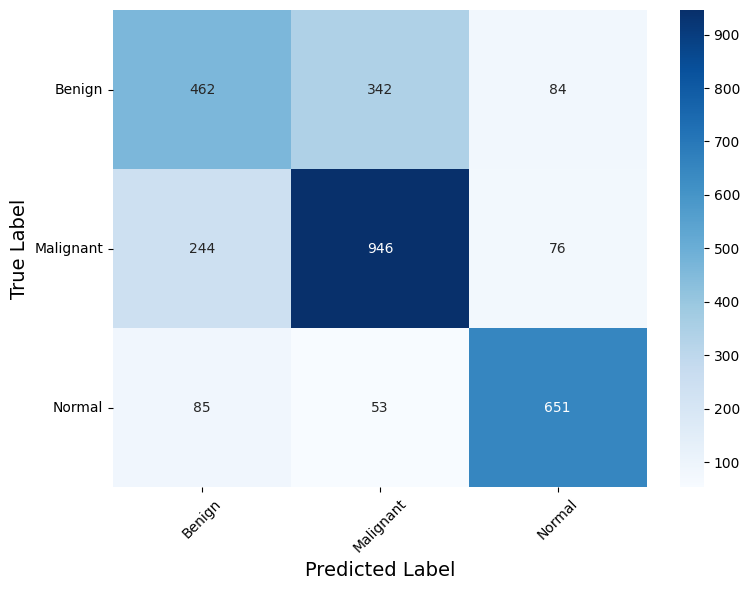

done1


In [18]:
# ==========================================================
# CONFUSION MATRIX PLOT
# ==========================================================
print("start")

cm = confusion_matrix(true_classes_test, predicted_classes_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)


plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45) # Rotate x-axis labels so they are easier to read
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("EfficientNetB3_SemiSupervised_confusion_matrix_test_(Balanced Dataset).pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")